# Ultralytics YOLO26 사용 예제

이 노트북은 **Ultralytics YOLO26** (2026년 1월 출시) 최신 모델을 사용한 객체 탐지 예제입니다.  
**Google Colab** 과 **Windows 로컬** 환경 모두에서 동작하도록 작성되었습니다.

| 항목 | 설명 |
|------|------|
| 패키지 | [`ultralytics`](https://github.com/ultralytics/ultralytics) — `pip install -U ultralytics` |
| 최신 모델 | **YOLO26** (`yolo26n.pt` ~ `yolo26x.pt`) |
| 문서 | [docs.ultralytics.com/models/yolo26](https://docs.ultralytics.com/models/yolo26/) |
| 지원 작업 | Detect, Segment, SemSeg, Classify, Pose, OBB, Track |

### YOLO26 핵심 특징
- **NMS-Free End-to-End**: 별도 NMS 후처리 없이 바로 탐지 결과 출력 , (NMS는 Non-Maximum Suppression)
- **DFL 제거**: 박스 회귀 단순화 → ONNX/TensorRT 등 **배포 용이**
- **엣지 최적화**: CPU 추론 속도 YOLO11 대비 **최대 43% 향상** (nano 기준)
- **통합 API**: YOLOv8/YOLO11과 동일한 `YOLO()` 인터페이스

## 0. 환경 설정 (Colab / Windows 공통)

| 환경 | 준비 사항 |
|------|----------|
| **Google Colab** | 런타임 → **GPU(T4 등)** 선택 후 셀 실행 |
| **Windows 로컬** | Python 3.8+ / PyTorch 설치된 Jupyter 또는 VS Code |

> YOLO26은 `ultralytics >= 8.3.0` 이상에서 지원됩니다. 아래 셀에서 최신 버전으로 업데이트합니다.

In [ ]:
# =============================================================================
# [셀 0-1] Ultralytics 패키지 설치
# - 최신 YOLO26 API를 사용하려면 ultralytics 패키지가 필요합니다.
# - Colab: 셀 실행 시 자동 설치 / Windows: 인터넷 연결 필요
# - 이미 설치되어 있으면 업그레이드만 수행합니다.
# =============================================================================
%pip install -U ultralytics


In [1]:
# =============================================================================
# [셀 0-2] 설치 버전 확인 (선택)
# - ultralytics 패키지가 정상 설치되었는지 버전 번호로 확인합니다.
# - YOLO26은 ultralytics >= 8.3.0 이상에서 지원됩니다.
# =============================================================================
import ultralytics

print(f"Ultralytics 버전: {ultralytics.__version__}")


Ultralytics 버전: 8.4.46


In [2]:
# =============================================================================
# [셀 0-3] 라이브러리 임포트 및 실행 환경 확인
# - Colab / Windows 로컬 환경을 자동 감지합니다.
# - GPU(CUDA) 사용 가능 여부에 따라 DEVICE를 자동 설정합니다.
# =============================================================================
import sys
from pathlib import Path

import torch
from IPython.display import Image, display
from ultralytics import YOLO, __version__

# ── 1) 실행 환경 감지 ────────────────────────────────────────
# google.colab 모듈이 있으면 Colab, 없으면 로컬 Jupyter/VS Code 환경
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Windows 여부 (경로 구분자, 영상 코덱 등 후속 처리에 참고)
IS_WINDOWS = sys.platform.startswith("win")

# ── 2) 연산 장치(Device) 설정 ─────────────────────────────────
# CUDA GPU가 있으면 0번 GPU, 없으면 CPU 사용
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ── 3) 환경 정보 출력 ─────────────────────────────────────────
print(f"실행 환경 : {'Google Colab' if IN_COLAB else '로컬'}")
print(f"OS        : {'Windows' if IS_WINDOWS else sys.platform}")
print(f"Ultralytics: {__version__}")
print(f"PyTorch   : {torch.__version__}")
print(f"Device    : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Colab에서 GPU 런타임이 제대로 선택됐는지 확인
if IN_COLAB:
    !nvidia-smi


실행 환경 : 로컬
OS        : Windows
Ultralytics: 8.4.46
PyTorch   : 2.11.0+cu126
Device    : 0 (NVIDIA GeForce RTX 3060)


In [3]:
# =============================================================================
# [셀 0-4] 공통 유틸리티 — 샘플 이미지 경로 & 결과 표시 함수
# - Colab에는 로컬 이미지가 없으므로 URL 다운로드 또는 프로젝트 경로를 자동 탐색
# - Windows 로컬에서는 yolov5/data/images 를 우선 사용
# =============================================================================
import urllib.request

# Ultralytics 공식 샘플 이미지 URL (인터넷만 있으면 Colab/Windows 모두 동작)
SAMPLE_URL_BUS = "https://ultralytics.com/images/bus.jpg"
SAMPLE_URL_ZIDANE = "https://ultralytics.com/images/zidane.jpg"

# 강의용 기본 탐지 모델: nano(n) — 가장 가볍고 빠름 (yolo26s/m/l/x 로 변경 가능)
MODEL_NAME = "yolo26n.pt"

def download_if_missing(url: str, save_path: Path) -> Path:
    """URL에서 파일을 다운로드합니다. 이미 존재하면 건너뜁니다."""
    if not save_path.exists():
        print(f"다운로드: {url} → {save_path}")
        urllib.request.urlretrieve(url, save_path)
    return save_path


def get_sample_images():
    """
    추론용 샘플 이미지 경로를 반환합니다.
    반환값: (bus 이미지 경로, zidane 이미지 경로, 이미지 폴더 경로)
    """
    # 1순위: 프로젝트 내 yolo 샘플 이미지 폴더
    local_dirs = [
        Path("yolo/data/images"),
        Path("../yolo/data/images"),
    ]
    for image_dir in local_dirs:
        bus = image_dir / "bus.jpg"
        zidane = image_dir / "zidane.jpg"
        if bus.exists():
            return bus, zidane if zidane.exists() else SAMPLE_URL_ZIDANE, image_dir

    # 2순위: sample_images/ 폴더에 URL에서 자동 다운로드
    sample_dir = Path("sample_images")
    sample_dir.mkdir(exist_ok=True)
    bus = download_if_missing(SAMPLE_URL_BUS, sample_dir / "bus.jpg")
    zidane = download_if_missing(SAMPLE_URL_ZIDANE, sample_dir / "zidane.jpg")
    return bus, zidane, sample_dir


def show_result(result, source_name: str, width: int = 600):
    """
    predict() 결과를 노트북에 이미지로 표시합니다.
    - result.save_dir: runs/detect/predict 등 결과 저장 폴더
    - source_name: 원본 파일명 (저장된 결과 이미지 이름과 동일)
    """
    saved = Path(result.save_dir) / Path(str(source_name)).name
    if saved.exists():
        display(Image(filename=str(saved), width=width))
    else:
        print(f"결과 파일 없음: {saved}")


# 전역 변수로 샘플 경로 설정 (이후 모든 섹션에서 재사용)
source_image, zidane_image, IMAGE_DIR = get_sample_images()
print(f"bus 이미지  : {source_image}")
print(f"zidane 이미지: {zidane_image}")
print(f"이미지 폴더  : {IMAGE_DIR}")


다운로드: https://ultralytics.com/images/bus.jpg → sample_images\bus.jpg
다운로드: https://ultralytics.com/images/zidane.jpg → sample_images\zidane.jpg
bus 이미지  : sample_images\bus.jpg
zidane 이미지: sample_images\zidane.jpg
이미지 폴더  : sample_images


## 1. YOLO26 모델 로드 & 객체 탐지 (Predict)

사전 학습 가중치를 자동으로 다운로드합니다. 강의에서는 **`yolo26n.pt`** (nano)를 사용합니다.

| 모델 | params | COCO mAP50-95 | 특징 |
|------|--------|---------------|------|
| yolo26n | 2.4M | 40.9% | 엣지/CPU 최적, 가장 빠름 |
| yolo26s | 9.5M | 48.6% | 속도·정확도 균형 |
| yolo26m | 20.4M | 53.1% | 중간 규모 |
| yolo26l | 24.8M | 55.0% | 고정확도 |
| yolo26x | 55.7M | 57.5% | 최고 정확도 |

In [4]:
# =============================================================================
# [섹션 1] YOLO26 사전학습 모델 로드
# - YOLO(MODEL_NAME) 호출 시 가중치(.pt)가 없으면 GitHub에서 자동 다운로드
# - yolo26n.pt : nano 모델 (2.4M 파라미터, 엣지/CPU 최적화)
# =============================================================================
model = YOLO(MODEL_NAME)



image 1/1 c:\MyCursorLab\06_Object_Detection\sample_images\bus.jpg: 640x480 4 persons, 1 bus, 74.9ms
Speed: 2.7ms preprocess, 74.9ms inference, 10.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\predict
탐지된 객체 수: 5


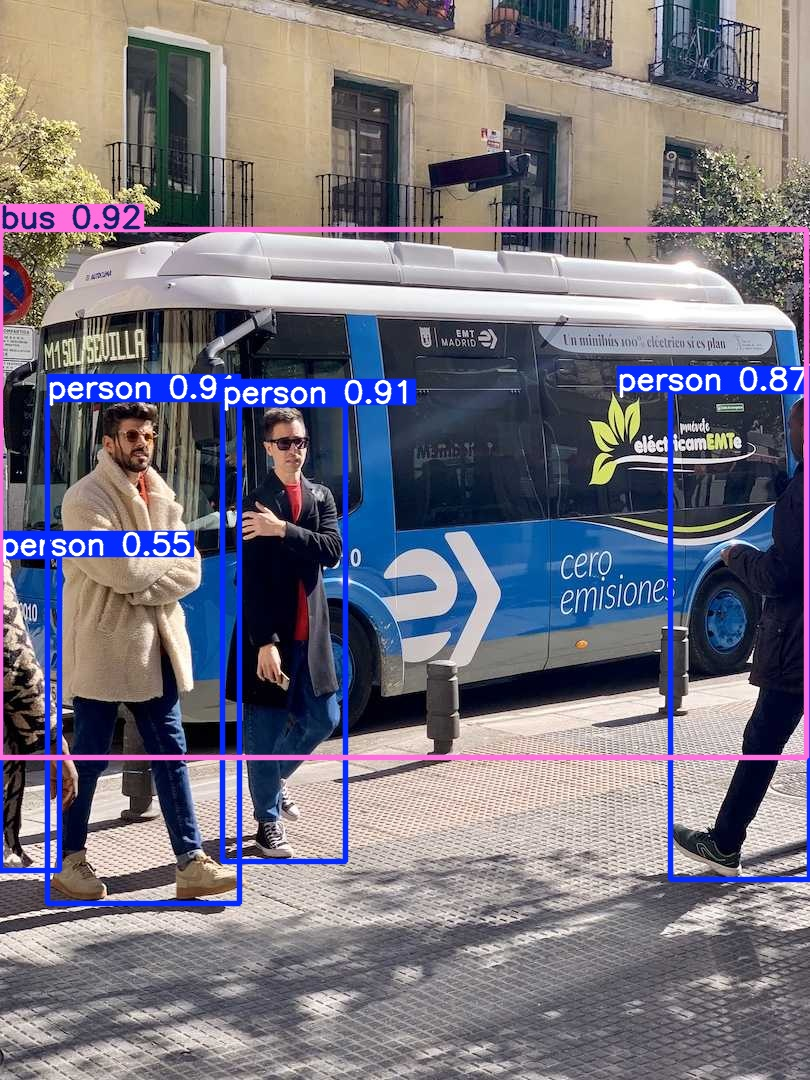

In [5]:
# =============================================================================
# [섹션 1] 단일 이미지 객체 탐지 (predict)
# - predict(): 추론 전용 메서드, 결과를 Results 객체 리스트로 반환
# - YOLO26은 NMS-Free End-to-End 구조 (별도 NMS 후처리 불필요)
# =============================================================================
results = model.predict(
    source=source_image,   # 입력: 파일 경로, URL, 폴더, 동영상, 웹캠(0) 등
    conf=0.25,             # 신뢰도 임계값: 0.25 미만 탐지는 제거
    imgsz=640,             # 입력 이미지 리사이즈 크기 (학습 시와 동일 권장)
    device=DEVICE,         # 0=GPU, "cpu"=CPU
    save=True,             # 바운딩 박스가 그려진 결과 이미지를 runs/ 에 저장
    show_labels=True,      # 클래스 이름 표시
    show_conf=True,        # 신뢰도 점수 표시
)

# results는 이미지 1장당 Results 객체 1개 → 리스트의 [0]번이 첫 번째 이미지 결과
result = results[0]
print(f"탐지된 객체 수: {len(result.boxes)}")
show_result(result, source_image)


## 2. 탐지 결과 해석

YOLO26은 **NMS-Free End-to-End** 구조이므로, 별도 NMS 후처리 없이 `result.boxes`에서 바로 결과를 읽을 수 있습니다.

In [6]:
# =============================================================================
# [섹션 2] 탐지 결과 상세 해석
# - result.boxes: 탐지된 모든 바운딩 박스 정보 (텐서)
# - xyxy: 좌상단(x1,y1), 우하단(x2,y2) 픽셀 좌표
# =============================================================================
names = result.names  # {0: 'person', 1: 'bicycle', ...} 클래스 ID → 이름 딕셔너리

for box in result.boxes:
    cls_id = int(box.cls[0])          # 클래스 ID (정수)
    conf = float(box.conf[0])         # 신뢰도 (0~1)
    xyxy = box.xyxy[0].tolist()       # [x1, y1, x2, y2] 바운딩 박스 좌표
    print(f"{names[cls_id]:12s} | conf={conf:.2f} | box={[round(v, 1) for v in xyxy]}")


bus          | conf=0.92 | box=[0.0, 229.4, 806.1, 757.1]
person       | conf=0.91 | box=[222.5, 404.9, 345.4, 861.7]
person       | conf=0.91 | box=[47.7, 399.3, 239.3, 903.0]
person       | conf=0.87 | box=[670.6, 391.5, 809.8, 879.0]
person       | conf=0.55 | box=[0.1, 556.7, 60.0, 870.1]


In [7]:
# =============================================================================
# [섹션 2] pandas DataFrame으로 결과 변환
# - 분석, 필터링, CSV 저장 등에 유용
# - to_df(): x1,y1,x2,y2, confidence, class, name 컬럼 포함
# =============================================================================
df = result.to_df()
df


name,class,confidence,box
str,i64,f64,struct[4]
"""bus""",5,0.9238,"{0.0,229.36795,806.07758,757.11816}"
"""person""",0,0.91259,"{222.46344,404.92514,345.40512,861.65137}"
"""person""",0,0.90542,"{47.68803,399.30765,239.32008,903.02118}"
"""person""",0,0.87015,"{670.64868,391.52795,809.80847,879.0061}"
"""person""",0,0.55176,"{0.12939,556.69031,59.99514,870.09698}"


## 3. 다양한 입력 소스 (Colab / Windows 공통)

`source` 인자에 아래 형식을 모두 사용할 수 있습니다.

```
로컬 이미지   : "sample_images/bus.jpg"  또는 Path 객체
이미지 폴더   : "sample_images/"
URL          : "https://ultralytics.com/images/bus.jpg"  ← Colab에서 권장
동영상        : "video.mp4"
웹캠          : 0
YouTube      : "https://youtu.be/..."
```

> **Colab 팁**: 로컬 파일이 없어도 URL 입력만으로 바로 실행 가능합니다.


Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 c:\MyCursorLab\06_Object_Detection\zidane.jpg: 384x640 2 persons, 1 tie, 89.1ms
Speed: 1.9ms preprocess, 89.1ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\predict


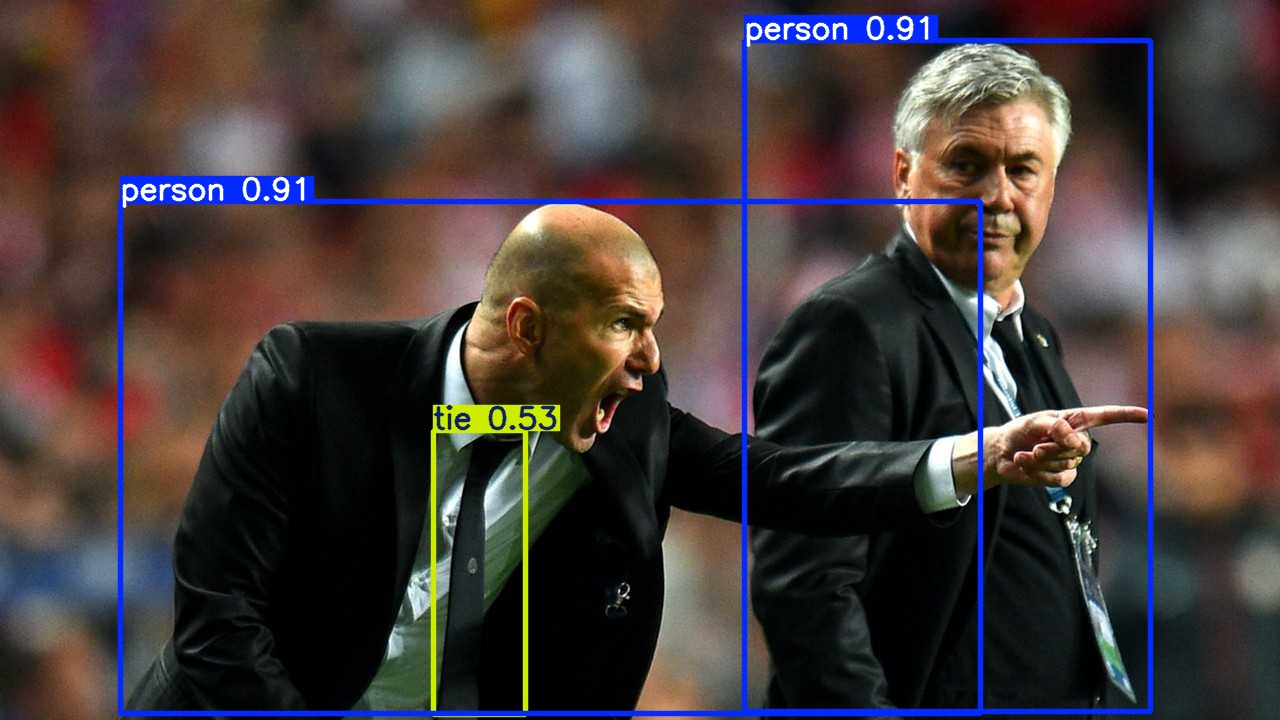

In [8]:
# =============================================================================
# [섹션 3] URL 이미지 추론
# - source에 HTTP URL을 직접 전달 가능 (Colab에서 특히 유용)
# - 로컬 파일 없이도 즉시 데모 가능
# =============================================================================
url_results = model.predict(
    source=SAMPLE_URL_ZIDANE,
    conf=0.25,
    device=DEVICE,
    save=True,
)
show_result(url_results[0], "zidane.jpg")


In [9]:
# =============================================================================
# [섹션 3] 폴더 내 여러 이미지 일괄 추론
# - source에 폴더 경로를 넘기면 내부 이미지를 순차 처리
# - 반환값: 이미지 수만큼의 Results 리스트
# =============================================================================
batch_results = model.predict(source=IMAGE_DIR, conf=0.25, device=DEVICE, save=True)
print(f"처리한 이미지 수: {len(batch_results)}")



image 1/2 c:\MyCursorLab\06_Object_Detection\sample_images\bus.jpg: 640x480 4 persons, 1 bus, 42.7ms
image 2/2 c:\MyCursorLab\06_Object_Detection\sample_images\zidane.jpg: 384x640 2 persons, 1 tie, 30.1ms
Speed: 4.5ms preprocess, 36.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\predict
처리한 이미지 수: 2


## 4. 모델 검증 (Validate)

COCO 사전 학습 모델의 성능을 **COCO128** 데이터셋으로 평가합니다 (첫 실행 시 자동 다운로드).

In [10]:
# =============================================================================
# [섹션 4] 모델 검증 (val)
# - 사전학습 모델의 성능을 데이터셋으로 평가
# - coco128.yaml: COCO 128장 서브셋 (빠른 sanity check용)
# - mAP50-95: IoU 0.5~0.95 평균 정밀도 / mAP50: IoU 0.5 기준 정밀도
# =============================================================================
metrics = model.val(data="coco128.yaml", imgsz=640, batch=16, device=DEVICE)
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50   : {metrics.box.map50:.4f}")


Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 726.1245.7 MB/s, size: 68.3 KB)
val: Scanning C:\Cursor_Test_Project\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 5.1s0.2s
                   all        128        929      0.684      0.543      0.637      0.479
                person         61        254      0.845      0.667      0.792      0.549
               bicycle          3          6      0.701      0.333      0.408      0.314
                   car         12         46      0.812      0.188       0.25      0.139
            motorcycle          4          5      0.672        0.8      0.938      0.716
              airplane          5          6      0.908      0.833      0.972      0.875
           

## 5. 모델 학습 (Train)

커스텀 데이터셋 또는 COCO128으로 파인튜닝합니다.

> **중요**: 섹션 1~4에서 사용한 `model` 객체는 추론/검증 후 **내부 구조가 변경(fuse)** 됩니다.  
> 이 상태에서 `model.train()`을 호출하면 사전학습 가중치가 **108/708개만 로드**되어 학습이 실패하고, 예측 시 **검출 0건**이 됩니다.  
> 반드시 아래처럼 **`YOLO(MODEL_NAME)`으로 새 모델을 생성**한 뒤 학습하세요.

> **Colab 주의**: 세션 시간 제한이 있으므로 `epochs`를 조절하거나 Google Drive에 결과를 저장하세요.

In [ ]:
# =============================================================================
# [섹션 5] 모델 학습 (train)
# ※ 중요: 섹션 1~4의 model 객체는 predict/val 후 내부 구조가 변경(fuse)됩니다.
#         같은 model로 train()하면 가중치 108/708만 로드되어 학습 실패!
#         반드시 YOLO(MODEL_NAME)으로 새 모델을 만들어 학습하세요.
# =============================================================================

# RTX 3060 기준 100 epoch 약 7분 소요 (환경에 따라 다름)

train_model = YOLO(MODEL_NAME)  # 사전학습 가중치에서 새로 로드 (708/708 전체 로드)

train_results = train_model.train(
    data="coco128.yaml",       # 데이터셋 설정 YAML (첫 실행 시 자동 다운로드)
    epochs=100,                # 전체 데이터 반복 학습 횟수
    imgsz=640,                 # 학습 이미지 크기
    batch=16,                  # 배치 크기 (GPU 메모리 부족 시 8로 줄이기)
    patience=50,               # Early Stopping: 50 epoch 개선 없으면 중단
    device=DEVICE,
    resume=False,              # 이전 학습 이어하기 방지 (새 학습 보장)
    project="runs",            # 결과 저장 상위 폴더
    name="yolo26_lecture_train",  # 실험 이름 (중복 시 -2, -3 자동 부여)
)

# best.pt: 검증 성능이 가장 좋았던 epoch의 가중치
best_weights = Path(train_results.save_dir) / "weights" / "best.pt"
print(f"최적 가중치: {best_weights.resolve()}")

# 학습 직후 검증 — mAP50 > 0.5 이면 정상 학습된 것
val_metrics = YOLO(best_weights).val(data="coco128.yaml", imgsz=640, device=DEVICE)
print(f"학습 후 mAP50-95: {val_metrics.box.map:.4f}")
print(f"학습 후 mAP50   : {val_metrics.box.map50:.4f}")


New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_l


image 1/1 c:\MyCursorLab\06_Object_Detection\yolov5\data\images\bus.jpg: 640x480 4 persons, 1 bus, 38.6ms
Speed: 6.4ms preprocess, 38.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\predict-11
학습 모델 탐지 수: 5
  - person: 0.94
  - person: 0.91
  - person: 0.83
  - bus: 0.81
  - person: 0.73


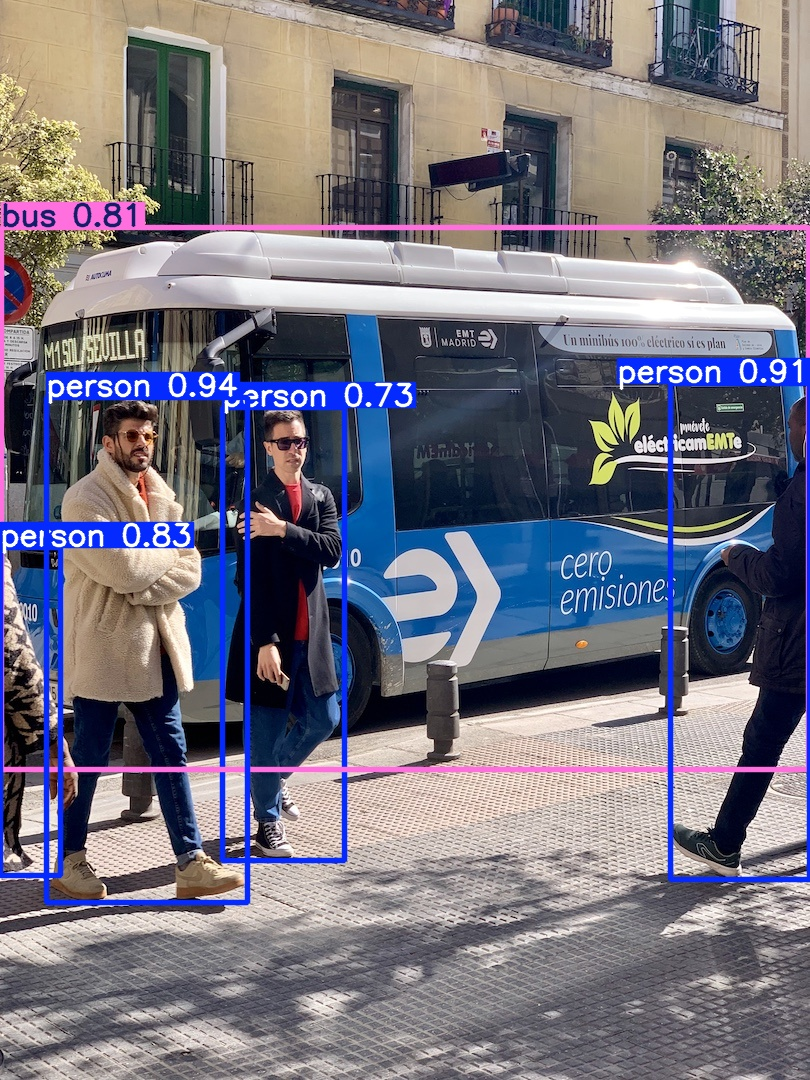

In [ ]:
# =============================================================================
# [섹션 5] 학습된 모델로 추론
# - best.pt를 새 YOLO 객체로 로드하여 파인튜닝된 가중치로 탐지
# =============================================================================
trained_model = YOLO(best_weights)
trained_results = trained_model.predict(
    source=source_image,
    conf=0.25,
    device=DEVICE,
    save=True,
)

trained_result = trained_results[0]
print(f"학습 모델 탐지 수: {len(trained_result.boxes)}")

# 검출 0건이면 학습 셀의 train_model = YOLO(MODEL_NAME) 확인 필요
if len(trained_result.boxes) == 0:
    print("⚠️ 검출 0건 → 학습 셀을 다시 실행했는지 확인하세요.")
    print("   (train_model = YOLO(MODEL_NAME) 로 새 모델을 만들어야 합니다)")
else:
    for box in trained_result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"  - {trained_result.names[cls_id]}: {conf:.2f}")

show_result(trained_result, source_image)


## 6. 인스턴스 세그멘테이션 (Segment)

객체의 **윤곽(마스크)** 까지 예측합니다.


image 1/1 c:\MyCursorLab\06_Object_Detection\sample_images\bus.jpg: 640x480 4 persons, 1 bus, 35.4ms
Speed: 2.4ms preprocess, 35.4ms inference, 7.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\segment\predict


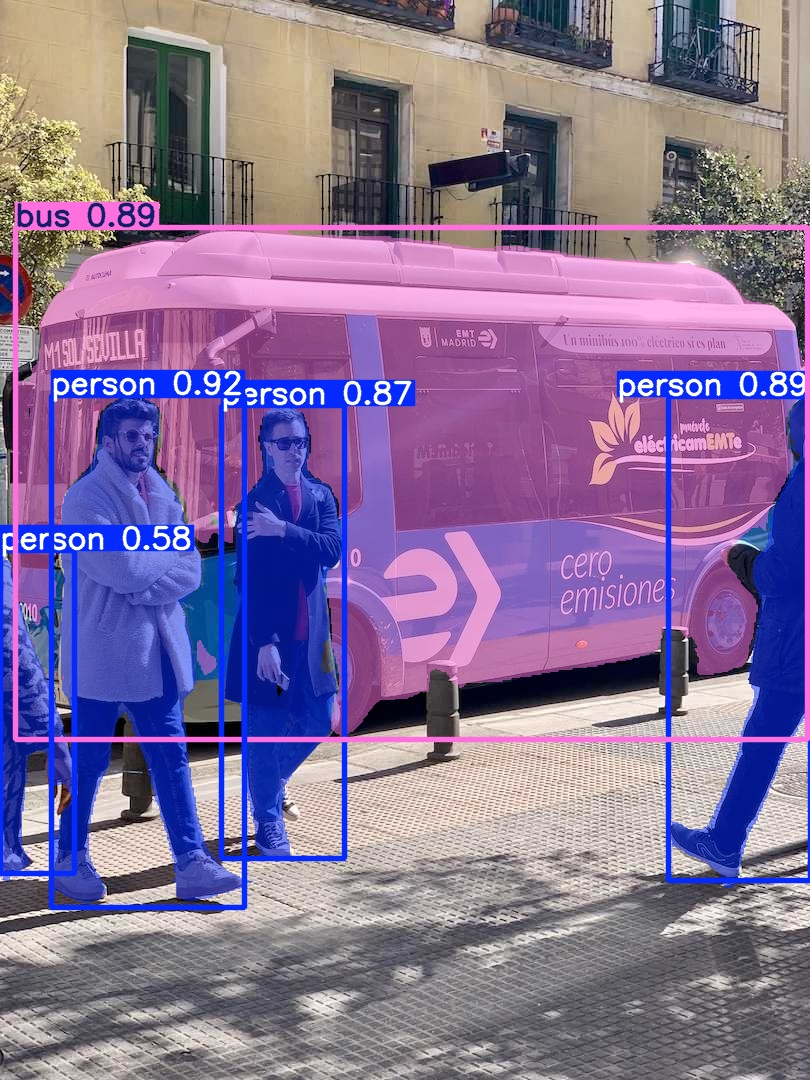

In [11]:
# =============================================================================
# [섹션 6] 인스턴스 세그멘테이션 (Segment)
# - yolo26n-seg.pt: 객체별 픽셀 마스크(윤곽)까지 예측
# - 탐지(박스) + 분할(마스크)을 동시에 수행
# =============================================================================
seg_model = YOLO("yolo26n-seg.pt")
seg_results = seg_model.predict(source=source_image, conf=0.25, device=DEVICE, save=True)
show_result(seg_results[0], source_image)


## 7. 이미지 분류 (Classify)

In [12]:
# =============================================================================
# [섹션 7] 이미지 분류 (Classify)
# - yolo26n-cls.pt: 이미지 전체를 하나의 클래스로 분류 (ImageNet 1000类)
# - probs: 각 클래스별 확률 분포
# =============================================================================
cls_model = YOLO("yolo26n-cls.pt")
cls_results = cls_model.predict(source=source_image, device=DEVICE, save=False)

probs = cls_results[0].probs
# top5: 상위 5개 클래스 ID / top5conf: 해당 확률값
for rank, (cls_id, conf) in enumerate(zip(probs.top5, probs.top5conf.tolist()), start=1):
    print(f"{rank}. {cls_model.names[cls_id]:20s} ({conf:.2%})")



image 1/1 c:\MyCursorLab\06_Object_Detection\sample_images\bus.jpg: 224x224 minibus 0.52, police_van 0.37, trolleybus 0.10, minivan 0.01, ambulance 0.00, 8.3ms
Speed: 8.6ms preprocess, 8.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
1. minibus              (51.58%)
2. police_van           (36.95%)
3. trolleybus           (9.60%)
4. minivan              (0.60%)
5. ambulance            (0.27%)


## 8. 포즈 추정 (Pose)

사람의 **키포인트(관절)** 를 탐지합니다. YOLO26은 RLE 기반으로 YOLO11 대비 최대 +7.2 AP 향상.


image 1/1 c:\MyCursorLab\06_Object_Detection\sample_images\zidane.jpg: 384x640 2 persons, 26.0ms
Speed: 3.7ms preprocess, 26.0ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\pose\predict


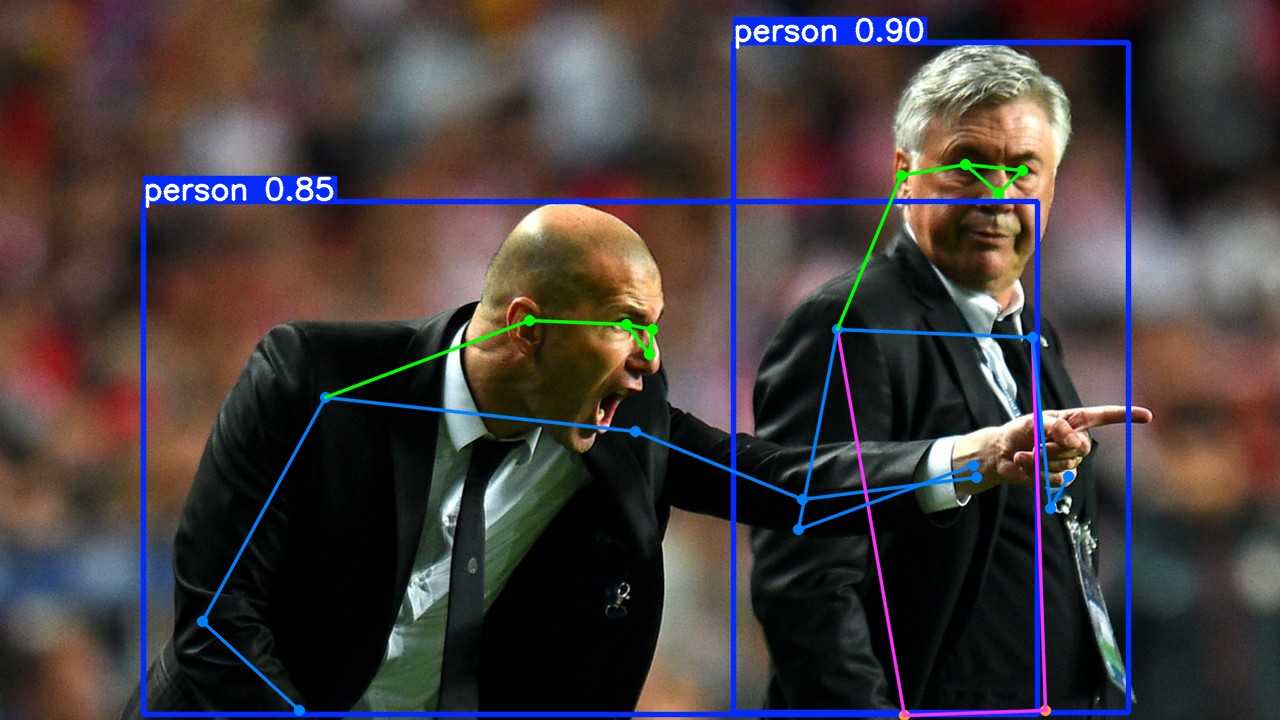

In [13]:
# =============================================================================
# [섹션 8] 포즈 추정 (Pose)
# - yolo26n-pose.pt: 사람의 17개 키포인트(관절) 탐지
# - zidane.jpg: 사람이 포함된 대표 샘플 이미지
# =============================================================================
pose_model = YOLO("yolo26n-pose.pt")
pose_results = pose_model.predict(
    source=zidane_image if isinstance(zidane_image, (str, Path)) else SAMPLE_URL_ZIDANE,
    conf=0.25,
    device=DEVICE,
    save=True,
)
show_result(pose_results[0], "zidane.jpg")


## 9. 방향 객체 탐지 (OBB)

**Oriented Bounding Box(OBB)** 는 회전된 사각형으로 객체를 표현합니다.  
YOLO26 OBB 모델(`yolo26n-obb.pt`)은 **DOTA v1** 항공 이미지 데이터셋으로 사전학습되었습니다.

| 출력 | 설명 |
|------|------|
| `result.obb.xywhr` | 중심x, 중심y, 너비, 높이, 회전각(radian) |
| `result.obb.xyxyxyxy` | 4꼭짓점 좌표 (다각형) |

> Colab / Windows 공통: Ultralytics 공식 샘플 `boats.jpg`(항공 촬영 선박)로 바로 실행합니다.


Found https://ultralytics.com/images/boats.jpg locally at boats.jpg
image 1/1 c:\MyCursorLab\06_Object_Detection\boats.jpg: 384x640 167 ships, 4 harbors, 37.6ms
Speed: 4.6ms preprocess, 37.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\obb\predict
OBB 탐지 수: 171
  ship         | conf=0.92 | xywhr=[781.36, 795.11, 41.04, 146.07, -0.23]
  ship         | conf=0.90 | xywhr=[1652.43, 939.35, 120.88, 36.16, 0.39]
  ship         | conf=0.90 | xywhr=[1793.48, 575.67, 120.93, 36.9, 0.44]
  ship         | conf=0.90 | xywhr=[1677.44, 864.46, 113.67, 34.7, 0.44]
  ship         | conf=0.90 | xywhr=[1618.65, 1001.34, 120.99, 36.09, 0.42]


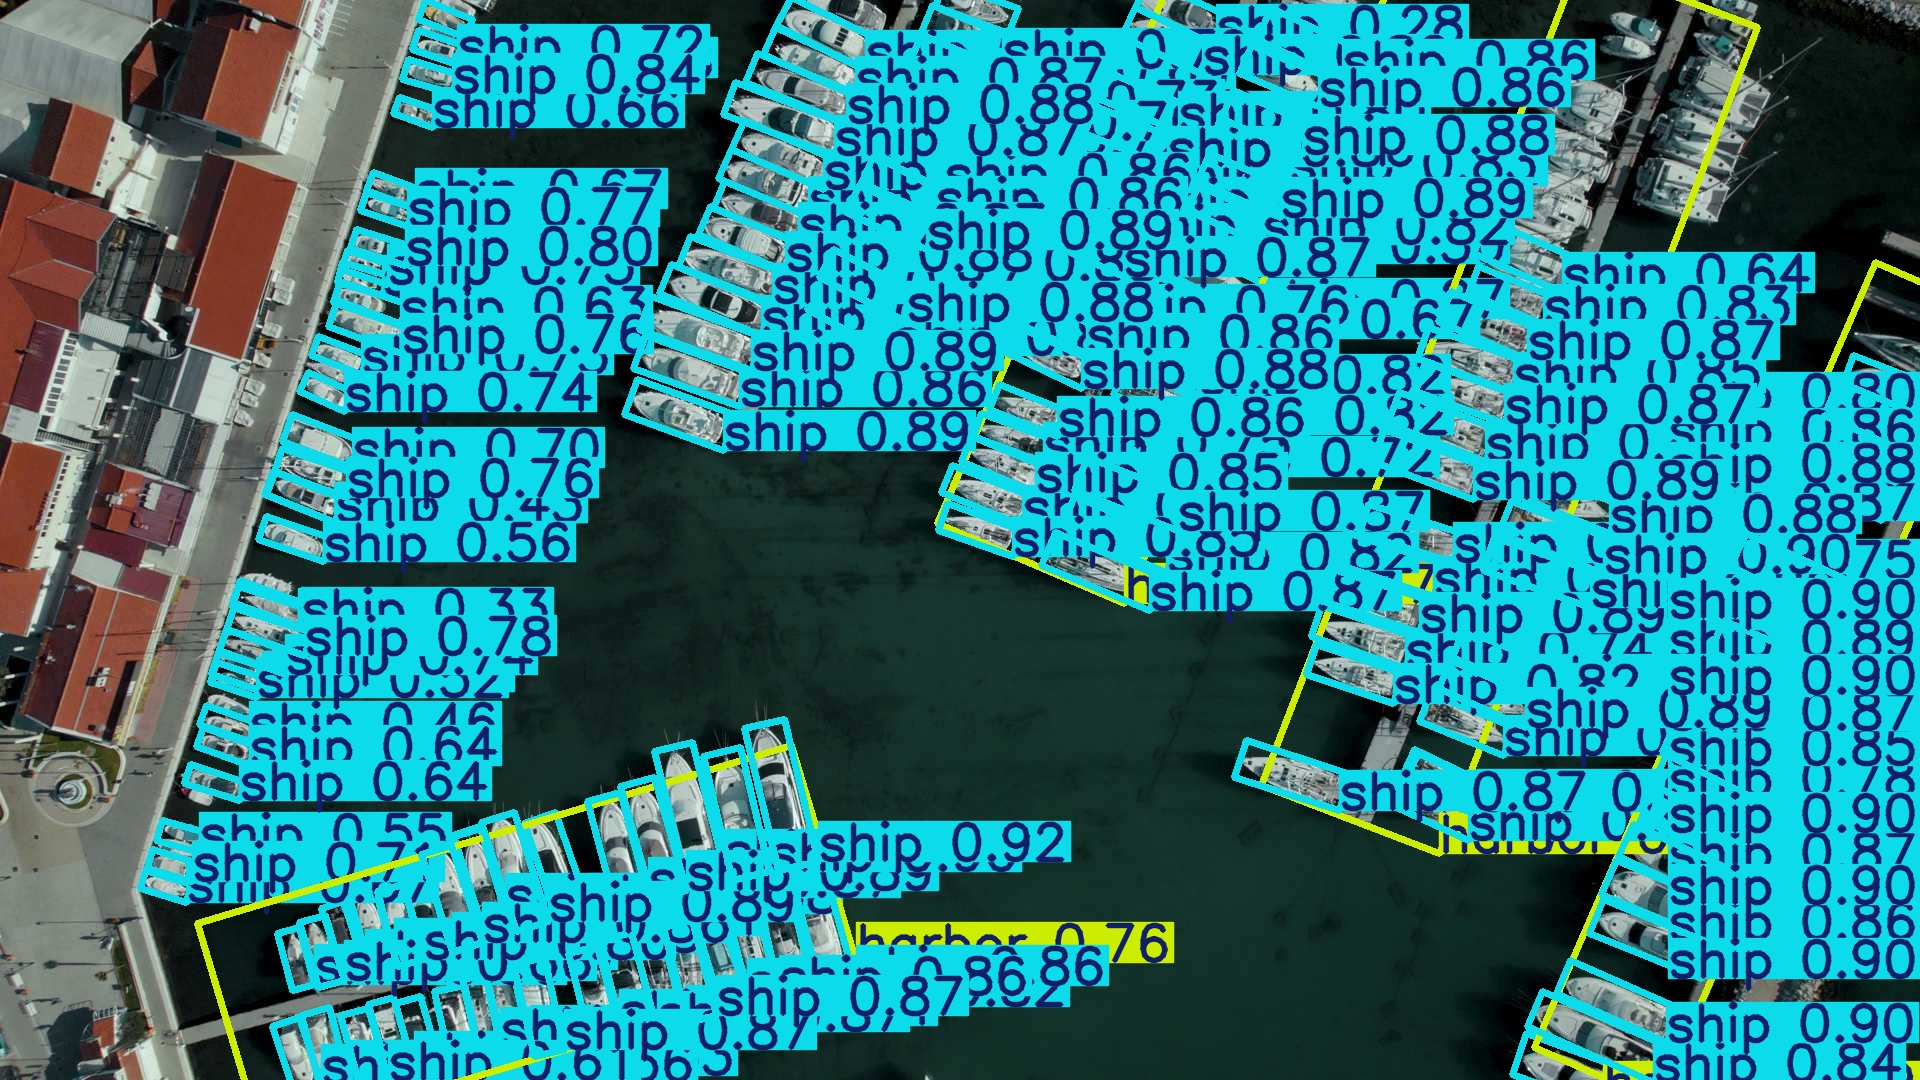

In [14]:
# =============================================================================
# [섹션 9] 방향 객체 탐지 (OBB — Oriented Bounding Box)
# - yolo26n-obb.pt: DOTA v1 항공/위성 이미지로 사전학습
# - 일반 bbox 대신 회전된 사각형으로 객체 표현 (xywhr: 중심, 크기, 각도)
# =============================================================================
OBB_SAMPLE_URL = "https://ultralytics.com/images/boats.jpg"  # 항공 촬영 선박 이미지

obb_model = YOLO("yolo26n-obb.pt")
obb_results = obb_model.predict(
    source=OBB_SAMPLE_URL,
    conf=0.25,
    imgsz=640,
    device=DEVICE,
    save=True,
)

obb_result = obb_results[0]
print(f"OBB 탐지 수: {len(obb_result.obb)}")

# result.obb: 회전 바운딩 박스 전용 속성 (일반 result.boxes 와 다름)
for i in range(min(5, len(obb_result.obb))):
    cls_id = int(obb_result.obb.cls[i])
    conf = float(obb_result.obb.conf[i])
    xywhr = obb_result.obb.xywhr[i].tolist()  # [cx, cy, w, h, angle_rad]
    print(
        f"  {obb_result.names[cls_id]:12s} | conf={conf:.2f} "
        f"| xywhr={[round(v, 2) for v in xywhr]}"
    )

show_result(obb_result, "boats.jpg")


## 10. 객체 추적 (Track)

동영상에서 **객체 ID를 유지**하며 프레임마다 추적합니다.  
ByteTrack / BoT-SORT 알고리즘을 YOLO26 탐지 결과와 결합합니다.

| 항목 | 설명 |
|------|------|
| 샘플 영상 | Ultralytics `solutions_ci_demo.mp4` (없으면 자동 다운로드) |
| tracker | `bytetrack.yaml` (기본), `botsort.yaml` |
| 출력 | `runs/detect/track/` 에 ID가 표시된 동영상 저장 |

> Colab / Windows 공통: YouTube 대신 **직접 MP4 다운로드** 방식을 사용해 안정적으로 실행합니다.

In [15]:
# =============================================================================
# [섹션 10] 객체 추적 (Track) — 동영상
# - track(): 매 프레임 탐지 + ByteTrack으로 동일 객체에 고유 ID 유지
# - stream=True: 프레임 단위 generator 반환 (긴 영상 메모리 절약)
# =============================================================================
%pip install -q lap  # 추적 알고리즘 의존 패키지 (Linear Assignment Problem)

import base64

import cv2
from IPython.display import HTML, display
from ultralytics.utils import ASSETS_URL
from ultralytics.utils.downloads import safe_download


def convert_to_preview_mp4(src: Path) -> Path:
    """
    AVI(WMV2) → MP4 변환.
    Windows에서 Ultralytics가 저장하는 .avi는 노트북 브라우저에서 재생 불가하므로
    HTML5 video 태그용 MP4로 변환합니다.
    """
    src = Path(src)
    preview_path = src.with_name(f"{src.stem}_preview.mp4")

    cap = cv2.VideoCapture(str(src))
    if not cap.isOpened():
        raise RuntimeError(f"영상을 열 수 없습니다: {src}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    for codec in ("avc1", "mp4v"):  # H.264 우선, 실패 시 MPEG-4
        trial = cv2.VideoWriter(
            str(preview_path),
            cv2.VideoWriter_fourcc(*codec),
            fps,
            (width, height),
        )
        if trial.isOpened():
            writer = trial
            break
        trial.release()

    if writer is None:
        cap.release()
        raise RuntimeError("MP4 변환용 VideoWriter 초기화 실패")

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        writer.write(frame)

    cap.release()
    writer.release()
    return preview_path


def show_video_in_notebook(video_path: Path, width: int = 640) -> None:
    """base64 인라인 HTML5 <video>로 노트북 내 재생 (VS Code/Colab 공통)."""
    video_path = Path(video_path)
    if not video_path.exists():
        print(f"결과 영상 없음: {video_path}")
        return

    play_path = (
        convert_to_preview_mp4(video_path)
        if video_path.suffix.lower() == ".avi"
        else video_path
    )

    video_b64 = base64.b64encode(play_path.read_bytes()).decode("ascii")
    display(
        HTML(
            f"""
            <video width="{width}" controls autoplay loop muted playsinline>
              <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
            </video>
            """
        )
    )
    print(f"노트북 재생 파일: {play_path.resolve()}")


def get_track_video() -> Path:
    """추적용 샘플 MP4 경로 (로컬 우선 → 없으면 Ultralytics assets 다운로드)."""
    local_candidates = [
        Path("solutions_ci_demo.mp4"),
        Path("sample_videos/solutions_ci_demo.mp4"),
        Path("sample-5s.mp4"),
        Path("sample-2s.mp4"),
    ]
    for video_path in local_candidates:
        if video_path.exists():
            return video_path.resolve()

    sample_dir = Path("sample_videos")
    sample_dir.mkdir(exist_ok=True)
    video_path = sample_dir / "solutions_ci_demo.mp4"
    if not video_path.exists():
        safe_download(f"{ASSETS_URL}/solutions_ci_demo.mp4", file=video_path)
    return video_path.resolve()


track_video = get_track_video()
print(f"추적 동영상: {track_video}")

track_model = YOLO(MODEL_NAME)
track_generator = track_model.track(
    source=track_video,
    conf=0.25,
    device=DEVICE,
    tracker="bytetrack.yaml",  # ByteTrack 알고리즘 (botsort.yaml 도 가능)
    save=True,                   # ID가 표시된 결과 영상 저장
    stream=True,                 # generator 모드 (프레임별 처리)
)

# generator를 끝까지 순회해야 전체 영상이 처리·저장됨
frame_count = 0
last_result = None
for result in track_generator:
    frame_count += 1
    last_result = result

print(f"처리 프레임 수: {frame_count}")

if last_result and last_result.boxes is not None and len(last_result.boxes):
    track_ids = last_result.boxes.id  # 각 박스에 부여된 추적 ID
    print(f"마지막 프레임 탐지: {len(last_result.boxes)}개")
    if track_ids is not None:
        print(f"추적 ID 예시: {track_ids[:5].tolist()}")

# Ultralytics 저장 경로: runs/detect/track/ (Windows는 .avi)
output_dir = Path(last_result.save_dir) if last_result else Path("runs/detect/track")
output_video = output_dir / f"{track_video.stem}.avi"
if not output_video.exists():
    output_video = output_dir / f"{track_video.stem}.mp4"

print(f"결과 동영상: {output_video.resolve()}")
if output_video.exists():
    show_video_in_notebook(output_video, width=640)
else:
    print("결과 동영상 파일을 찾을 수 없습니다. save_dir 내 파일을 확인하세요.")


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.
추적 동영상: C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4

video 1/1 (frame 1/62) C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4: 384x640 18 persons, 30.4ms
video 1/1 (frame 2/62) C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4: 384x640 18 persons, 10.5ms
video 1/1 (frame 3/62) C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4: 384x640 16 persons, 12.9ms
video 1/1 (frame 4/62) C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4: 384x640 17 persons, 8.5ms
video 1/1 (frame 5/62) C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4: 384x640 17 persons, 10.6ms
video 1/1 (frame 6/62) C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4: 384x640 17 persons, 8.7ms
video 1/1 (frame 7/62) C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4: 384x640 18 persons, 8.6ms
video 1/1 (frame 8/62) C:\MyCursorLab\06_Object_Detection\solutions_ci_demo.mp4: 384x640 18 persons, 8.7ms
video 1/

노트북 재생 파일: C:\MyCursorLab\06_Object_Detection\runs\detect\track\solutions_ci_demo_preview.mp4


## 11. 모델보내기 (Export)

YOLO26의 NMS-Free 구조는 ONNX, TensorRT, CoreML 등 **엣지 배포**에 특히 유리합니다.

In [14]:
# =============================================================================
# [섹션 11] 모델보내기 (Export) — ONNX
# - 학습된/사전학습 모델을 배포용 포맷으로 변환
# - ONNX: TensorRT, OpenVINO, ONNX Runtime 등에서 사용
# - YOLO26 NMS-Free 구조는 ONNX 변환이 단순함 (DFL 제거)
# =============================================================================
onnx_path = model.export(format="onnx", imgsz=640)
print(f"ONNX 모델 저장: {onnx_path}")


Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CPU (12th Gen Intel Core i5-1235U)



PyTorch: starting from 'yolo26n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.3 MB)

ONNX: starting export with onnx 1.21.0 opset 20...


c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  2.2s, saved as 'yolo26n.onnx' (9.5 MB)

Export complete (2.4s)
Results saved to C:\MyCursorLab\06_Object_Detection\yolo26n.onnx
Predict:         yolo predict task=detect model=yolo26n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolo26n.onnx imgsz=640 data=/home/lq/codes/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app
ONNX 모델 저장: yolo26n.onnx


## 12. CLI (명령줄) — Colab / Windows 공통

노트북 셀에서 `!` 접두사로 실행하거나, 터미널/PowerShell에서 직접 실행합니다.

```bash
# 추론
yolo predict model=yolo26n.pt source=sample_images/bus.jpg conf=0.25

# 학습
yolo train model=yolo26n.pt data=coco128.yaml epochs=50 imgsz=640

# 검증
yolo val model=yolo26n.pt data=coco128.yaml

# 추적
yolo track model=yolo26n.pt source=video.mp4

#보내기
yolo export model=yolo26n.pt format=onnx
```

> **Windows PowerShell**: 위 명령을 그대로 사용할 수 있습니다.  
> **Colab**: `!yolo predict model=yolo26n.pt source=https://ultralytics.com/images/bus.jpg` 형태로 URL도 가능합니다.

In [15]:
# =============================================================================
# [섹션 12] CLI(명령줄) 추론 데모
# - 노트북 없이 터미널에서도 동일한 작업 가능: yolo predict/train/val/track/export
# - ! 접두사: Jupyter 셀에서 셸 명령 실행
# =============================================================================
source_arg = str(source_image).replace("\\", "/")  # Windows 백슬래시 → 슬래시
!yolo predict model=yolo26n.pt source={source_arg} conf=0.25 device={DEVICE} save=True


Ultralytics 8.4.60  Python-3.10.11 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs

image 1/1 c:\MyCursorLab\06_Object_Detection\yolov5\data\images\bus.jpg: 640x480 4 persons, 1 bus, 69.9ms
Speed: 2.9ms preprocess, 69.9ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\predict-13
 Learn more at https://docs.ultralytics.com/modes/predict


## 13. 커스텀 데이터셋 학습 가이드

```
my_dataset/
├── images/
│   ├── train/
│   └── val/
└── labels/
    ├── train/   # 이미지와 동일 이름의 .txt (YOLO 정규화 좌표)
    └── val/
```

`my_data.yaml`:
```yaml
path: ./my_dataset
train: images/train
val: images/val
names:
  0: cat
  1: dog
```

```python
model = YOLO("yolo26n.pt")
model.train(data="my_data.yaml", epochs=100, imgsz=640, device=0)
```

## 14. YOLO 버전 비교

| 구분 | YOLOv3/v5 (레포 클론) | YOLO11 | **YOLO26 (최신)** |
|------|----------------------|--------|-------------------|
| 설치 | `git clone` + requirements | `pip install ultralytics` | 동일 |
| 추론 | `python detect.py` | `model.predict()` | `model.predict()` |
| NMS | 별도 후처리 필요 | NMS 사용 | **NMS-Free End-to-End** |
| CPU 속도 | 보통 | 기준 | **최대 43% 빠름** |
| 배포 | 복잡 | 보통 | **DFL 제거, 단순화** |


이 노트북은 **YOLO26 최신 Ultralytics API** 예제입니다.

## 참고 자료

- [YOLO26 공식 문서](https://docs.ultralytics.com/models/yolo26/)
- [Ultralytics Python API](https://docs.ultralytics.com/usage/python/)
- [CLI 가이드](https://docs.ultralytics.com/usage/cli/)
- [Colab 공식 튜토리얼](https://colab.research.google.com/github/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb)
- [YOLO26 블로그](https://www.ultralytics.com/blog/ultralytics-yolo26-the-new-standard-for-edge-first-vision-ai)